## Cluster Analysis Summary

K=3 is used because:
- The elbow plot shows diminishing returns in WCSS after K=3.
- Three clusters provide a clean, interpretable behavioral segmentation.

### Cluster Profiles
* **Cluster 0 (The High-Octane Chugger):** Defined by high caffeine intake, elevated resting heart rate, and the lowest average sleep duration.
* **Cluster 1 (The Decaf Abstainer):** Defined by zero coffee consumption, balanced sleep patterns, and lower resting heart rates.
* **Cluster 2 (The Balanced Brewer):** Defined by moderate, sustainable coffee intake with health metrics closely resembling the abstainer group.

In [11]:
import joblib
import os
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [12]:
# 1. Load the engineered data
df = pd.read_csv('../data/processed/features_engineered.csv')

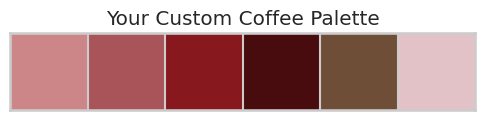

In [32]:
# 1. Define a custom list of hex codes (The "Coffee Palette")
custom_palette = [
    "#CD8688",
    "#A85458",
    '#87181D',
    "#480B0E",
    '#6F4E37',
    '#E2C2C6'
]

# 2. Set this as the global default for all Seaborn plots
sns.set_palette(custom_palette)
sns.set_style("whitegrid") # Clean white background

# 3. Quick test to see your new colors
sns.palplot(custom_palette)
plt.title("Your Custom Coffee Palette")
plt.show()

In [14]:
# 2. Select numerical features that define a user's physical state and habits
cluster_features = [
    'Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 
    'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Caffeine_per_Cup'
]

X = df[cluster_features].copy()

In [15]:
# 3. Standardize the data 
# (K-Means uses distance, so we must ensure Caffeine_mg doesn't overpower Sleep_Hours)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✓ Data loaded and scaled. Shape: {X_scaled.shape}")

✓ Data loaded and scaled. Shape: (10000, 8)


In [16]:
wcss = [] # Within-Cluster Sum of Squares (how tight the clusters are)
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

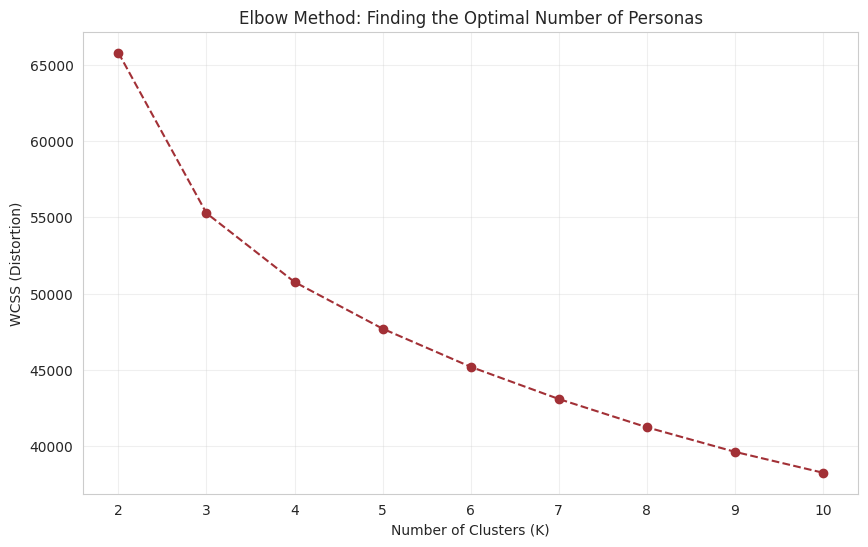

In [17]:
# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color=custom_palette[1])
plt.title('Elbow Method: Finding the Optimal Number of Personas')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Distortion)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# 1. Fit the final K-Means model with 4 clusters
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Add the predicted cluster labels (0, 1, 2, or 3) directly into our main dataframe
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [19]:
# 2. Use PCA to reduce our 8 features down to 2 dimensions for plotting
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

df['PCA1'] = pca_features[:, 0]
df['PCA2'] = pca_features[:, 1]

In [25]:
# 1. Create a mapping dictionary based on your needs
# Adjust the values (e.g., 'None', 'Moderate', 'High') to match your actual data clusters
persona_map = {
    1: 'None (Low)', 
    2: 'Moderate', 
    0: 'High'
}

# 2. Create the clean column for plotting
df['Persona_Name'] = df['Cluster'].map(persona_map)

/tmp/ipykernel_6537/4082249296.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  scatter = sns.scatterplot(


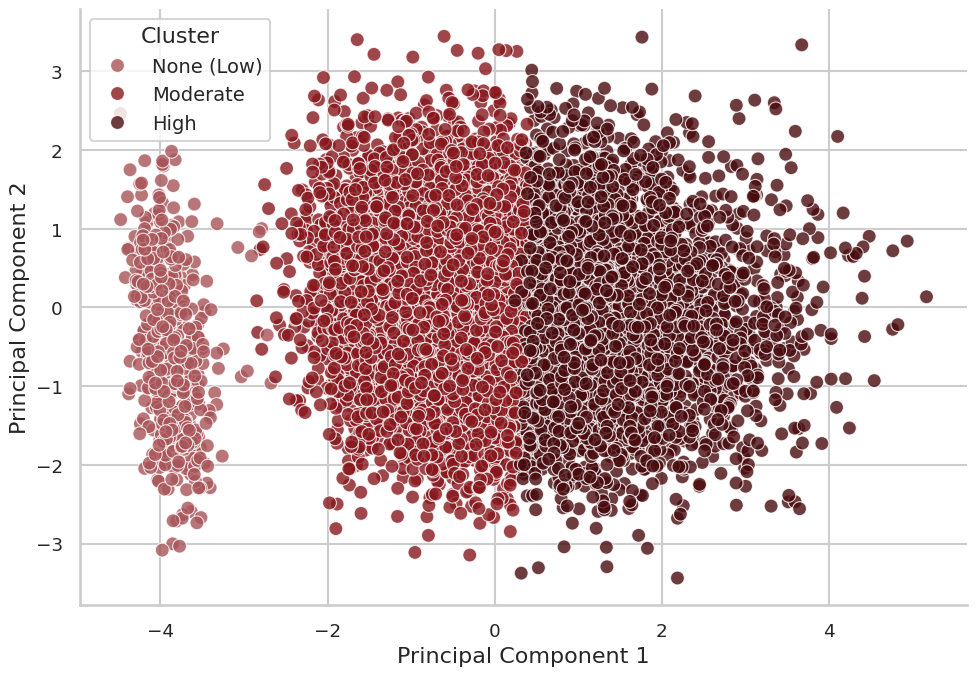

In [33]:
# 3. Define the custom order so the legend and plot show None -> Moderate -> High
persona_order = ['None (Low)', 'Moderate', 'High']

# 4. Plot using the new names and order
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Persona_Name',          # Use the new label column
    data=df, 
    hue_order=persona_order,    # Force the logic order
    palette=custom_palette[1:], 
    alpha=0.8, 
    s=100
)

# 4. Clean Titles and Labels
plt.xlabel('Principal Component 1', fontsize=16)
plt.ylabel('Principal Component 2', fontsize=16)

# 5. Clean up the legend
plt.legend(
    title='Cluster', 
    title_fontsize='16', 
    fontsize='14', 
    loc='best', 
    frameon=True
)

# Remove top and right spines for a clean academic look
sns.despine()

plt.tight_layout()
plt.savefig('pca_coffee_personas.png', dpi=300, bbox_inches='tight') # High-res for thesis
plt.show()

In [ ]:
# 1. Initialize and fit UMAP
# n_neighbors and min_dist are standard baseline parameters
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = reducer.fit_transform(X_scaled)

# 2. Add the new coordinates to your dataframe
df['UMAP1'] = umap_features[:, 0]
df['UMAP2'] = umap_features[:, 1]

# 3. Resave your sampled CSV for Streamlit
output_path = '../data/processed/features_engineered_with_clusters.csv'
df_sampled = df.sample(n=1000, random_state=42)
df_sampled.to_csv(output_path, index=False)

print(f"Sampled UMAP cluster data saved to {output_path}")

/media/nata/7AAE88B3AE886989/Навчання/4 курс/Diploma/DS-Research-NS/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sampled UMAP cluster data saved to ../data/processed/features_engineered_with_clusters.csv


In [ ]:
# Country distribution by cluster
print("Country Distribution by Cluster:")
cluster_country_profile = df.groupby('Cluster')['Country'].value_counts().unstack().fillna(0)
display(cluster_country_profile)

Country Distribution by Cluster:


Country,Australia,Belgium,Brazil,Canada,China,Finland,France,Germany,India,Italy,Japan,Mexico,Netherlands,Norway,South Korea,Spain,Sweden,Switzerland,UK,USA
Cluster,,,,,,,,,,,,,,,,,,,,
0,211,200,207,236,235,211,211,207,218,204,204,190,195,233,197,221,212,220,228,193
1,30,32,20,38,26,31,22,31,28,31,31,29,29,25,26,27,35,24,23,28
2,256,265,229,269,260,268,266,259,278,274,234,264,270,265,289,238,266,256,268,227


In [ ]:
# Calculate the average values for our original features, grouped by Cluster
cluster_profile = df.groupby('Cluster')[cluster_features].mean()

# Display the table cleanly
display(cluster_profile.round(2))

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Caffeine_per_Cup
Cluster,,,,,,,,
0,34.62,3.85,365.72,6.21,23.86,71.69,7.52,95.01
1,34.74,0.00,0.19,6.98,23.87,69.42,7.43,0.71
2,35.24,1.69,160.72,6.95,24.10,69.88,7.47,95.10


In [ ]:
# Now we look at the 'answer keys' to see how the Personas actually feel!
outcome_features = ['Sleep_Quality_Num', 'Stress_Level_Num', 'Health_Issues_Num']

outcomes_profile = df.groupby('Cluster')[outcome_features].mean()
display(outcomes_profile.round(2))

,Sleep_Quality_Num,Stress_Level_Num,Health_Issues_Num
Cluster,,,
0,1.48,0.58,0.57
1,1.92,0.29,0.37
2,1.93,0.26,0.37


In [ ]:
# Create the models directory if it doesn't exist (though you likely have it from Week 6)
os.makedirs('../models/clustering', exist_ok=True)

# Save the StandardScaler (Crucial: we must use the exact same scaler for new users)
joblib.dump(scaler, '../models/clustering/cluster_scaler.joblib')

# Save the K-Means model
joblib.dump(kmeans, '../models/clustering/kmeans_model.joblib')

['../models/clustering/kmeans_model.joblib']

In [ ]:
# Define the profiles based on the analysis we just did
cluster_metadata = {
    'profiles': {
        0: {"name": "The High-Octane Chugger", "description": "High caffeine, low sleep, elevated heart rate."},
        1: {"name": "The Decaf Abstainer", "description": "Zero coffee, balanced sleep, low heart rate."},
        2: {"name": "The Balanced Brewer", "description": "Moderate coffee, well-rested, normal heart rate."}
    },
    # Saving the averages so you can use them in Streamlit later! (Issue #12)
    'feature_means': df.groupby('Cluster')[cluster_features].mean().to_dict()
}

# Save it in the same folder as your models
joblib.dump(cluster_metadata, '../models/clustering/cluster_metadata.joblib')

print("✓ Cluster metadata saved!")

✓ Cluster metadata saved!


In [ ]:
output_path = '../data/processed/features_engineered_with_clusters.csv'
df_sampled = df.sample(n=1000, random_state=42)
df_sampled.to_csv(output_path, index=False)

print(f"✓ Cluster data saved to {output_path}")

✓ Cluster data saved to ../data/processed/features_engineered_with_clusters.csv
